In [3]:
import glob
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MaxNLocator

# import os
# while not os.path.isdir('.git'):
#     os.chdir('../..')

import matplotlib as mpl
mpl.rcParams["font.family"] = "Avenir"

In [4]:
project = "temporal-interference-1"

In [8]:
subthreshold = []

for file in glob.glob(f"../output/{project}/variable-time-ef/*_*_*.csv"):
    pattern = re.compile(r"([^/]+)_([^/]+)_([^/]+)\.csv$")
    phi, psi, carrier = pattern.search(file).groups()

    data = pd.read_csv(file)
    data["Phi"] = int(phi)
    data["Psi"] = int(psi)
    data["Carrier"] = int(carrier)

    subthreshold.append(data)

subthreshold = pd.concat(subthreshold, ignore_index = True)
subthreshold

,Psi,Phi,Carrier,Beat,SubthresholdAmplitude,SubthresholdAmplitudeStep,LastAP
0,90,90,2000,0.0,794.433594,0.244141,False
1,90,90,2000,0.5,233.154297,0.122070,False
2,90,90,2000,1.0,231.933594,0.244141,False
3,90,90,2000,2.0,231.201172,0.122070,False
4,90,90,2000,3.0,230.834961,0.061035,False
...,...,...,...,...,...,...,...
227,90,90,9000,100.0,828.170776,0.007629,False
228,90,90,9000,110.0,830.444336,0.061035,False
229,90,90,9000,120.0,832.763672,0.122070,False
230,90,90,9000,130.0,834.350586,0.061035,False


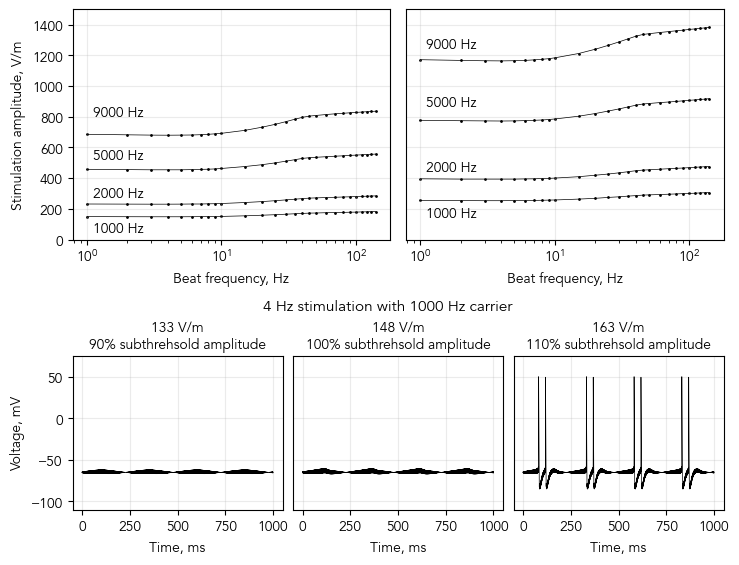

In [25]:
fig = plt.figure(figsize = (8.4, 6.5))

outer_gs = gridspec.GridSpec(3, 1, height_ratios = [1.2, 0.3, 0.8])

# --- B panel (1 row, 2 plots) ---
inner_gs = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec = outer_gs[0], wspace = 0.05, width_ratios = [1, 1])
ax_b1 = fig.add_subplot(inner_gs[0])
ax = ax_b1

carriers = [1000, 2000, 5000, 9000]
color = "black"

x = 1.1
ys = {
    1000: 20,
    2000: 250,
    5000: 500,
    9000: 775
}

for carrier in carriers:
    dt = subthreshold[
        (subthreshold.Phi == 90) &
        (subthreshold.Psi == 90) &
        (subthreshold.Carrier == carrier) &
        (subthreshold.Beat > 0.5)
    ]

    ax.plot(dt.Beat, dt.SubthresholdAmplitude, linewidth = 0.5, color = color)
    ax.scatter(dt.Beat, dt.SubthresholdAmplitude, s = 1, color = color)
    
    ax.text(
        x, ys[carrier],
        f"{carrier} Hz",
        fontsize = 10,
        horizontalalignment = "left",
        verticalalignment = "bottom"
    )

ax.set_xlabel("Beat frequency, Hz")
ax.set_ylabel("Stimulation amplitude, V/m")
ax.set_xscale("log")
ax.grid(alpha = 0.25)
ax.set_ylim(0, 1500)

ax_b2 = fig.add_subplot(inner_gs[1])
ax = ax_b2

x = 1.1
ys = {
    1000: 120,
    2000: 420,
    5000: 840,
    9000: 1220
}

for carrier in carriers:
    dt = subthreshold[
        (subthreshold.Phi == 0) &
        (subthreshold.Psi == 180) &
        (subthreshold.Carrier == carrier) &
        (subthreshold.Beat > 0.5)
    ]

    ax.plot(dt.Beat, dt.SubthresholdAmplitude, linewidth = 0.5, color = color)
    ax.scatter(dt.Beat, dt.SubthresholdAmplitude, s = 1, color = color)

    ax.text(
        x, ys[carrier],
        f"{carrier} Hz",
        fontsize = 10,
        horizontalalignment = "left",
        verticalalignment = "bottom"
    )

ax.set_xlabel("Beat frequency, Hz")
ax.set_xscale("log")
ax.grid(alpha = 0.25)
ax.set_ylim(0, 1500)
ax.tick_params(left = False, labelleft = False)

# --- C panel (1 row title + 3 horizontal plots) ---
inner_gs = gridspec.GridSpecFromSubplotSpec(1, 3, subplot_spec = outer_gs[2], wspace = 0.05)
ax_d1 = fig.add_subplot(inner_gs[0])
ax_d2 = fig.add_subplot(inner_gs[1])
ax_d3 = fig.add_subplot(inner_gs[2])

axs = [ax_d1, ax_d2, ax_d3]

voltage0_9 = pd.read_csv("../output/temporal-interference-1/figures/figure1/voltage_trace_1000_4Hz_0.9.csv")
voltage1 = pd.read_csv("../output/temporal-interference-1/figures/figure1/voltage_trace_1000_4Hz_1.csv")
voltage1_1 = pd.read_csv("../output/temporal-interference-1/figures/figure1/voltage_trace_1000_4Hz_1.1.csv")

for ax, voltage in zip(axs, [voltage0_9, voltage1, voltage1_1]):
    ax.plot(
        voltage.Time,
        voltage.Voltage,
        color = "black",
        linewidth = 0.5
    )

    ax.set_ylim(-110, 75)
    ax.set_xlabel("Time, ms")
    ax.grid(alpha = 0.25)

axs[1].tick_params(left = False, labelleft = False)
axs[2].tick_params(left = False, labelleft = False)

axs[0].set_title("133 V/m\n90% subthrehsold amplitude", fontsize = 10)
axs[1].set_title("148 V/m\n100% subthrehsold amplitude", fontsize = 10)
axs[2].set_title("163 V/m\n110% subthrehsold amplitude", fontsize = 10)

axs[0].yaxis.set_visible(True)
axs[0].set_ylabel("Voltage, mV")

fig.text(
    0.5, 0.41,
    "4 Hz stimulation with 1000 Hz carrier",
    ha = "center",
    va = "bottom",
    fontsize = 11
)

plt.subplots_adjust(wspace = 0.1)
plt.savefig("results_subthreshold-ef.png", dpi = 500, bbox_inches = "tight")